# Multivariate HAL API Demo

This notebook demonstrates the reusable `haldensity.multivariate` API on synthetic bivariate data. It mirrors the case-study examples: import the package, generate data, inspect the basis, fit models, and visualize the fitted density.

In [1]:
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import sys

from IPython.display import display
from sklearn.model_selection import KFold

root = pathlib.Path(".").resolve().parent
sys.path.append(str(root))

np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.haldensity.multivariate import (
    BivariateTruncatedNormal,
    MultvarHAL,
    create_multivariate_basis,
    default_sobol_budget,
    summarize_basis_catalog,
    summarize_design_matrix,
    theoretical_basis_count,
)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate Bivariate Data

We will simulate data from a truncated bivariate normal on `[0, 1]^2` and use that distribution as a reference for visual comparisons.

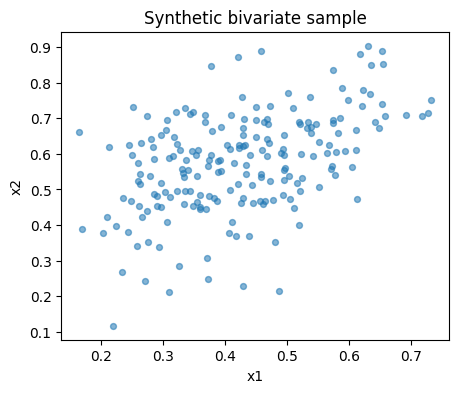

,x1,x2
0,0.477353,0.470246
1,0.262007,0.543342
2,0.733071,0.751574
3,0.433801,0.541965
4,0.494633,0.525311


mean_x1                      0.420000
mean_x2                      0.580000
variance_x1                  0.018000
variance_x2                  0.022000
covariance_x1_x2             0.008000
lower_x1                     0.000000
lower_x2                     0.000000
upper_x1                     1.000000
upper_x2                     1.000000
truncation_probability       0.996762
training_samples           200.000000
holdout_samples           1500.000000
Name: value, dtype: float64

In [2]:
dgp = BivariateTruncatedNormal(
    mean=(0.42, 0.58),
    covariance=[[0.018, 0.008], [0.008, 0.022]],
    lower=(0.0, 0.0),
    upper=(1.0, 1.0),
)
support = dgp.bounds
n_samples = 200
holdout_samples = 1500
data = dgp.generate_samples(n_samples, seed=42)
holdout_data = dgp.generate_samples(holdout_samples, seed=314)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(data["x1"], data["x2"], s=18, alpha=0.55)
ax.set_title("Synthetic bivariate sample")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()

display(data.head())
display(
    pd.Series(
        {
            **dgp.get_stats(),
            "training_samples": n_samples,
            "holdout_samples": holdout_samples,
        },
        name="value",
    )
)

## Basis Preview

Before fitting the estimator, we can inspect the reusable basis builder directly and verify that the returned width matches the finite initialized multivariate HAL count.

In [3]:
basis_order = 2
basis_matrix, basis_names, basis_meta = create_multivariate_basis(data, k=basis_order)
expected_width = theoretical_basis_count(
    n=len(data),
    d=data.shape[1],
    k=basis_order,
)
assert basis_matrix.shape[1] == expected_width

basis_summary = summarize_basis_catalog(basis_meta)
basis_preview = basis_meta.loc[
    :11,
    ["basis_index", "term_type", "section", "section_size", "exponents", "knot_row", "name"],
].copy()
design_summary = (
    pd.Series(summarize_design_matrix(basis_matrix), name="value")
    .rename_axis("metric")
    .to_frame()
)

print(f"k = {basis_order} basis width: {basis_matrix.shape[1]}")
display(basis_summary)
display(basis_preview)
display(design_summary)

k = 2 basis width: 1409


,term_type,section_size,count
0,poly,0,9
1,section-1,1,1200
2,full,2,200


,basis_index,term_type,section,section_size,exponents,knot_row,name
0,0,poly,(),0,"(0, 0)",NaN,Intercept
1,1,poly,(),0,"(0, 1)",NaN,x2
2,2,poly,(),0,"(0, 2)",NaN,x2^2
3,3,poly,(),0,"(1, 0)",NaN,x1
4,4,poly,(),0,"(1, 1)",NaN,x1 * x2
5,5,poly,(),0,"(1, 2)",NaN,x1 * x2^2
6,6,poly,(),0,"(2, 0)",NaN,x1^2
7,7,poly,(),0,"(2, 1)",NaN,x1^2 * x2
8,8,poly,(),0,"(2, 2)",NaN,x1^2 * x2^2
9,9,section-1,"(x1,)",1,"(0,)",0.0,(x1 - 0.477)_+^2


,value
metric,
n_rows,200.000000
n_cols,1409.000000
min_col_norm,0.000000
median_col_norm,0.140668
max_col_norm,14.142136
near_zero_variance_fraction,0.024840
correlation_subset_size,20.000000
max_abs_correlation_subset,0.999544
median_abs_correlation_subset,0.747846


## Tune And Fit `MultvarHAL`

This section keeps the packaged multivariate estimator API, but adds a notebook-local Optuna cross-validation loop like the univariate example. We tune `k` and the L1 norm budget by validation log-likelihood, then optionally apply a conservative post-CV shrinkage of the norm constraint while keeping the chosen basis order fixed before refitting the selected configuration on the full sample.

In [4]:
TUNING_CONFIG = {
    "cv_folds": 5,
    "n_trials": 24,
    "cv_seed": 42,
    "quadrature_points_per_dim": 48,
    "basis_orders": [1, 2],
    "norm_constraint_low": 2.0,
    "norm_constraint_high": 1e3,
    "norm_constraint_log": True,
    "cv_curve_orders": [0, 1, 2],
    "cv_curve_points": 8,
    "cv_curve_k0_orders": [0],
    "cv_curve_k0_sobol_budget_multiplier": 4,
    "use_conservative_adjustment": True,
    "conservative_k_percent": 0.05,
    "conservative_max_steps": 18,
    "conservative_step_pct": 0.05,
    "conservative_bracket_factor": 0.5,
}
ESTIMATOR_BASE_CONFIG = {
    "support": support,
    "quadrature_points_per_dim": TUNING_CONFIG["quadrature_points_per_dim"],
    "solver": "MOSEK",
    "use_secondary_solver": True,
    "selection_tol": 1e-4,
}

surface_points_per_dim = 80
surface_axis_x1 = np.linspace(support[0][0], support[0][1], surface_points_per_dim)
surface_axis_x2 = np.linspace(support[1][0], support[1][1], surface_points_per_dim)
surface_mesh_x1, surface_mesh_x2 = np.meshgrid(surface_axis_x1, surface_axis_x2, indexing="xy")
surface_grid = np.column_stack([surface_mesh_x1.ravel(), surface_mesh_x2.ravel()])
true_density_surface = dgp.compute_density(surface_grid).reshape(surface_mesh_x1.shape)


def average_log_likelihood(model, evaluation_data):
    density = np.clip(model.get_density_at_points(evaluation_data), 1e-12, None)
    return float(np.mean(np.log(density)))


def summarize_fitted_model(model):
    fitted_density_surface = model.get_density_at_points(surface_grid).reshape(surface_mesh_x1.shape)
    pointwise_abs_error = np.abs(fitted_density_surface - true_density_surface)
    pointwise_sq_error = (fitted_density_surface - true_density_surface) ** 2

    summary = model.summary().copy()
    summary["fine_midpoint_integral"] = model.normalization_integral(points_per_dim=60)
    summary["holdout_avg_loglik"] = average_log_likelihood(model, holdout_data)
    summary["pointwise_mae"] = float(np.mean(pointwise_abs_error))
    summary["pointwise_rmse"] = float(np.sqrt(np.mean(pointwise_sq_error)))
    summary["pointwise_max_abs_error"] = float(np.max(pointwise_abs_error))
    return fitted_density_surface, summary


kfold = KFold(
    n_splits=TUNING_CONFIG["cv_folds"],
    shuffle=True,
    random_state=TUNING_CONFIG["cv_seed"],
)
cv_score_cache = {}


def cv_score_with_sd(order, norm_constraint, estimator_overrides=None):
    estimator_overrides = {} if estimator_overrides is None else dict(estimator_overrides)
    override_key = tuple(sorted(estimator_overrides.items()))
    cache_key = (int(order), float(np.round(float(norm_constraint), 12)), override_key)
    cached = cv_score_cache.get(cache_key)
    if cached is not None:
        return cached

    fold_scores = []
    estimator_config = {**ESTIMATOR_BASE_CONFIG, **estimator_overrides}
    for train_idx, val_idx in kfold.split(data):
        train_fold = data.iloc[train_idx].reset_index(drop=True)
        val_fold = data.iloc[val_idx].reset_index(drop=True)
        try:
            fold_model = MultvarHAL(
                k=int(order),
                norm_constraint=float(norm_constraint),
                **estimator_config,
            ).fit(train_fold)
            fold_scores.append(average_log_likelihood(fold_model, val_fold))
        except Exception:
            fold_scores.append(float("-inf"))

    valid_scores = [score for score in fold_scores if np.isfinite(score)]
    mean_score = float(np.mean(valid_scores)) if valid_scores else float("-inf")
    sd_score = float(np.std(valid_scores, ddof=1)) if len(valid_scores) >= 2 else 0.0
    result = (mean_score, sd_score, fold_scores)
    cv_score_cache[cache_key] = result
    return result


def objective(trial):
    order = trial.suggest_categorical("k", TUNING_CONFIG["basis_orders"])
    norm_constraint = trial.suggest_float(
        "norm_constraint",
        TUNING_CONFIG["norm_constraint_low"],
        TUNING_CONFIG["norm_constraint_high"],
        log=TUNING_CONFIG["norm_constraint_log"],
    )
    mean_score, _, fold_scores = cv_score_with_sd(order, norm_constraint)
    if not np.isfinite(mean_score):
        trial.set_user_attr("failure_reason", "non_finite_cv_score")
        trial.set_user_attr("fold_scores", fold_scores)
        return np.inf
    return -float(mean_score)


def apply_conservative_adjustment(optuna_params):
    order = int(optuna_params["k"])
    optuna_nc = float(optuna_params["norm_constraint"])
    optuna_cv_mean, optuna_cv_sd, _ = cv_score_with_sd(order, optuna_nc)
    threshold = float(optuna_cv_mean - TUNING_CONFIG["conservative_k_percent"] * optuna_cv_sd)
    min_norm_constraint = float(TUNING_CONFIG["norm_constraint_low"])
    adjustment_rows = []

    def evaluate_norm_constraint(norm_constraint, step):
        norm_constraint = float(max(norm_constraint, min_norm_constraint))
        mean_score, sd_score, _ = cv_score_with_sd(order, norm_constraint)
        above_threshold = bool(mean_score >= threshold)
        adjustment_rows.append(
            {
                "step": int(step),
                "norm_constraint": float(norm_constraint),
                "cv_avg_loglik": float(mean_score),
                "cv_sd": float(sd_score),
                "above_threshold": above_threshold,
                "threshold": float(threshold),
            }
        )
        return mean_score, sd_score, above_threshold

    step = 0
    evaluate_norm_constraint(optuna_nc, step)
    step += 1

    best_good_nc = float(optuna_nc)
    bad_nc = None
    while step <= TUNING_CONFIG["conservative_max_steps"]:
        candidate = float(max(
            best_good_nc * TUNING_CONFIG["conservative_bracket_factor"],
            min_norm_constraint,
        ))
        if np.isclose(candidate, best_good_nc):
            break
        _, _, above_threshold = evaluate_norm_constraint(candidate, step)
        step += 1
        if above_threshold:
            best_good_nc = candidate
            continue
        bad_nc = candidate
        break

    if bad_nc is None:
        conservative_nc = float(best_good_nc)
    else:
        good_nc = float(best_good_nc)
        bad_nc = float(bad_nc)
        relative_tolerance = float(max(TUNING_CONFIG["conservative_step_pct"], 1e-6))
        while step <= TUNING_CONFIG["conservative_max_steps"]:
            relative_gap = (good_nc - bad_nc) / max(good_nc, min_norm_constraint)
            if relative_gap <= relative_tolerance:
                break
            midpoint = float(np.exp((np.log(bad_nc) + np.log(good_nc)) / 2.0))
            _, _, above_threshold = evaluate_norm_constraint(midpoint, step)
            step += 1
            if above_threshold:
                good_nc = midpoint
            else:
                bad_nc = midpoint
        conservative_nc = float(good_nc)

    conservative_cv_mean, conservative_cv_sd, _ = cv_score_with_sd(order, conservative_nc)
    return {
        "params": {"k": order, "norm_constraint": conservative_nc},
        "threshold": float(threshold),
        "optuna_cv_avg_loglik": float(optuna_cv_mean),
        "optuna_cv_sd": float(optuna_cv_sd),
        "conservative_cv_avg_loglik": float(conservative_cv_mean),
        "conservative_cv_sd": float(conservative_cv_sd),
        "trace": pd.DataFrame(adjustment_rows),
    }


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=TUNING_CONFIG["cv_seed"]),
)
study.optimize(objective, n_trials=TUNING_CONFIG["n_trials"], show_progress_bar=False)

optuna_params = {
    "k": int(study.best_trial.params["k"]),
    "norm_constraint": float(study.best_trial.params["norm_constraint"]),
}
optuna_cv_avg_loglik = float(-study.best_value)
optuna_cv_avg_loglik, optuna_cv_sd, _ = cv_score_with_sd(
    optuna_params["k"],
    optuna_params["norm_constraint"],
)

conservative_adjustment = None
selection_method = "optuna_best"
selected_params = optuna_params.copy()
selected_cv_avg_loglik = float(optuna_cv_avg_loglik)
selected_cv_sd = float(optuna_cv_sd)

if TUNING_CONFIG["use_conservative_adjustment"]:
    conservative_adjustment = apply_conservative_adjustment(optuna_params)
    selected_params = conservative_adjustment["params"].copy()
    selected_cv_avg_loglik = float(conservative_adjustment["conservative_cv_avg_loglik"])
    selected_cv_sd = float(conservative_adjustment["conservative_cv_sd"])
    selection_method = "conservative_adjusted"

optuna_model = MultvarHAL(
    k=optuna_params["k"],
    norm_constraint=optuna_params["norm_constraint"],
    **ESTIMATOR_BASE_CONFIG,
).fit(data)
optuna_surface, optuna_summary = summarize_fitted_model(optuna_model)
optuna_summary["cv_avg_loglik"] = float(optuna_cv_avg_loglik)
optuna_summary["cv_sd"] = float(optuna_cv_sd)
optuna_summary["selection_method"] = "optuna_best"

same_as_optuna = (
    selected_params["k"] == optuna_params["k"]
    and np.isclose(selected_params["norm_constraint"], optuna_params["norm_constraint"])
)
if same_as_optuna:
    best_model = optuna_model
    best_surface = optuna_surface
    best_summary = optuna_summary.copy()
else:
    best_model = MultvarHAL(
        k=selected_params["k"],
        norm_constraint=selected_params["norm_constraint"],
        **ESTIMATOR_BASE_CONFIG,
    ).fit(data)
    best_surface, best_summary = summarize_fitted_model(best_model)

best_summary["cv_avg_loglik"] = float(selected_cv_avg_loglik)
best_summary["cv_sd"] = float(selected_cv_sd)
best_summary["selection_method"] = selection_method
best_results = best_model.get_results()
best_params = selected_params.copy()

trial_rows = []
for trial in study.trials:
    if trial.value is None or not np.isfinite(trial.value):
        continue
    trial_rows.append(
        {
            "trial": trial.number,
            "cv_avg_loglik": float(-trial.value),
            "k": int(trial.params["k"]),
            "norm_constraint": float(trial.params["norm_constraint"]),
        }
    )

top_trials_df = (
    pd.DataFrame(trial_rows)
    .sort_values("cv_avg_loglik", ascending=False)
    .reset_index(drop=True)
)
selection_rows = [
    {
        "selection": "optuna_best",
        "k": optuna_params["k"],
        "norm_constraint": optuna_params["norm_constraint"],
        "cv_avg_loglik": float(optuna_summary["cv_avg_loglik"]),
        "cv_sd": float(optuna_summary["cv_sd"]),
        "selected_basis_count": int(optuna_summary["selected_basis_count"]),
        "holdout_avg_loglik": float(optuna_summary["holdout_avg_loglik"]),
        "pointwise_rmse": float(optuna_summary["pointwise_rmse"]),
    }
]
if selection_method != "optuna_best":
    selection_rows.append(
        {
            "selection": selection_method,
            "k": best_params["k"],
            "norm_constraint": best_params["norm_constraint"],
            "cv_avg_loglik": float(best_summary["cv_avg_loglik"]),
            "cv_sd": float(best_summary["cv_sd"]),
            "selected_basis_count": int(best_summary["selected_basis_count"]),
            "holdout_avg_loglik": float(best_summary["holdout_avg_loglik"]),
            "pointwise_rmse": float(best_summary["pointwise_rmse"]),
        }
    )
selection_comparison_df = pd.DataFrame(selection_rows)

best_summary_df = (
    pd.Series(
        {
            **best_summary,
            "optuna_k": optuna_params["k"],
            "optuna_norm_constraint": optuna_params["norm_constraint"],
            "selected_k": best_params["k"],
            "selected_norm_constraint": best_params["norm_constraint"],
            "conservative_threshold": None
            if conservative_adjustment is None
            else float(conservative_adjustment["threshold"]),
        },
        name="value",
    )
    .rename_axis("metric")
    .to_frame()
)

print("CV tuning config:", TUNING_CONFIG)
print("Optuna best parameters:", optuna_params)
if conservative_adjustment is not None:
    print("Conservative selected parameters:", best_params)
    print("Conservative threshold:", round(conservative_adjustment["threshold"], 6))
print("Selected CV average log-likelihood:", round(best_summary["cv_avg_loglik"], 6))
display(top_trials_df.head(10))
display(selection_comparison_df)
if conservative_adjustment is not None:
    display(conservative_adjustment["trace"])
display(best_summary_df)

CV tuning config: {'cv_folds': 5, 'n_trials': 24, 'cv_seed': 42, 'quadrature_points_per_dim': 48, 'basis_orders': [1, 2], 'norm_constraint_low': 2.0, 'norm_constraint_high': 1000.0, 'norm_constraint_log': True, 'cv_curve_orders': [0, 1, 2], 'cv_curve_points': 8, 'cv_curve_k0_orders': [0], 'cv_curve_k0_sobol_budget_multiplier': 4, 'use_conservative_adjustment': True, 'conservative_k_percent': 0.05, 'conservative_max_steps': 18, 'conservative_step_pct': 0.05, 'conservative_bracket_factor': 0.5}
Optuna best parameters: {'k': 2, 'norm_constraint': 294.94674091841955}
Conservative selected parameters: {'k': 2, 'norm_constraint': 227.43502838158878}
Conservative threshold: 1.326933
Selected CV average log-likelihood: 1.327495


,trial,cv_avg_loglik,k,norm_constraint
0,22,1.332431,2,294.946741
1,21,1.331736,2,339.407667
2,23,1.331568,2,346.292135
3,14,1.330935,2,261.710471
4,15,1.329717,2,248.125050
5,10,1.328176,2,411.343047
6,11,1.326858,2,447.163368
7,13,1.326028,2,216.117886
8,12,1.324194,2,576.177548
9,16,1.323961,2,202.777555


,selection,k,norm_constraint,cv_avg_loglik,cv_sd,selected_basis_count,holdout_avg_loglik,pointwise_rmse
0,optuna_best,2,294.946741,1.332431,0.109951,132,1.180260,0.37908
1,conservative_adjusted,2,227.435028,1.327495,0.114394,126,1.194043,0.34079


,step,norm_constraint,cv_avg_loglik,cv_sd,above_threshold,threshold
0,0,294.946741,1.332431,0.109951,True,1.326933
1,1,147.473370,1.313872,0.116755,False,1.326933
2,2,208.558841,1.324894,0.115407,False,1.326933
3,3,248.019657,1.329708,0.113143,True,1.326933
4,4,227.435028,1.327495,0.114394,True,1.326933
5,5,217.792529,1.326251,0.114916,False,1.326933


,value
metric,
k,2
solver_requested,MOSEK
solver_used,ECOS
solver_status,optimal
normalizer_requested,auto
normalizer_method_used,sobol
normalizer_size,512
normalizer_auto_reason,auto: k>=1 and d>1 uses sobol budget 512
exact_candidate_budget,None


## CV Log-Likelihood Vs L1 Norm

To visualize how the cross-validation objective changes with the L1 norm budget, we evaluate diagnostic CV curves for `k = 0, 1, 2`. The `k = 0` curve uses a Sobol bank that is four times larger than the default bank used elsewhere in this notebook, while `k = 1, 2` keep the usual setup. The markers highlight the raw CV-best choice and the final CV-adjusted choice when they exist for a given order.

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/h

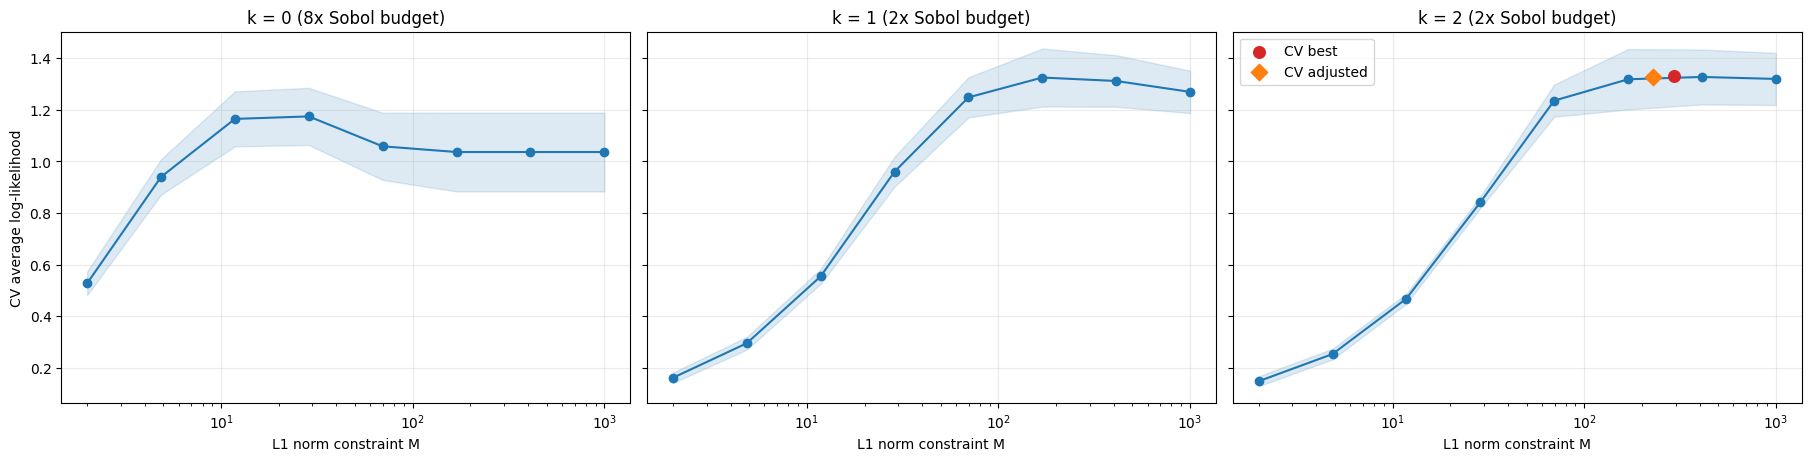

In [5]:
from concurrent.futures import ThreadPoolExecutor

cv_curve_grid = np.geomspace(
    TUNING_CONFIG["norm_constraint_low"],
    TUNING_CONFIG["norm_constraint_high"],
    TUNING_CONFIG["cv_curve_points"],
)
cv_curve_k0_orders = set(TUNING_CONFIG["cv_curve_k0_orders"])
cv_curve_standard_sobol_budget_multiplier = 2  # change k=1,2 multiplier here
cv_curve_k0_sobol_budget_multiplier = 8  # change k=0 multiplier here
cv_curve_max_workers = 8  # change plot parallelism here

default_curve_sobol_budget = default_sobol_budget(len(support))


def curve_estimator_overrides(order):
    sobol_budget_multiplier = (
        cv_curve_k0_sobol_budget_multiplier
        if order in cv_curve_k0_orders
        else cv_curve_standard_sobol_budget_multiplier
    )
    return {
        "normalizer": "sobol",
        "sobol_budget": sobol_budget_multiplier * default_curve_sobol_budget,
    }


def compute_cv_curve_row(task):
    order, norm_constraint = task
    estimator_overrides = curve_estimator_overrides(order)
    cv_mean, cv_sd, _ = cv_score_with_sd(
        order,
        float(norm_constraint),
        estimator_overrides=estimator_overrides,
    )
    return {
        "k": int(order),
        "norm_constraint": float(norm_constraint),
        "cv_avg_loglik": float(cv_mean),
        "cv_sd": float(cv_sd),
        "sobol_budget": estimator_overrides["sobol_budget"],
    }


tasks = [
    (order, float(norm_constraint))
    for order in TUNING_CONFIG["cv_curve_orders"]
    for norm_constraint in cv_curve_grid
]
max_workers = max(1, min(cv_curve_max_workers, len(tasks)))
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    cv_curve_rows = list(executor.map(compute_cv_curve_row, tasks))

cv_curve_df = pd.DataFrame(cv_curve_rows)
fig, axes = plt.subplots(
    1,
    len(TUNING_CONFIG["cv_curve_orders"]),
    figsize=(6 * len(TUNING_CONFIG["cv_curve_orders"]), 4.5),
    sharey=True,
    constrained_layout=True,
)
if len(TUNING_CONFIG["cv_curve_orders"]) == 1:
    axes = [axes]

for ax, order in zip(axes, TUNING_CONFIG["cv_curve_orders"]):
    order_curve = cv_curve_df.loc[cv_curve_df["k"] == order].sort_values("norm_constraint")
    order_overrides = curve_estimator_overrides(order)
    order_budget = int(order_curve["sobol_budget"].iloc[0])
    budget_multiplier = int(order_budget / default_curve_sobol_budget)
    x_values = order_curve["norm_constraint"].to_numpy(dtype=float)
    y_values = order_curve["cv_avg_loglik"].to_numpy(dtype=float)
    sd_values = order_curve["cv_sd"].to_numpy(dtype=float)

    ax.plot(x_values, y_values, marker="o", color="tab:blue")
    ax.fill_between(
        x_values,
        y_values - sd_values,
        y_values + sd_values,
        color="tab:blue",
        alpha=0.15,
    )

    if order == optuna_params["k"]:
        curve_optuna_cv_avg_loglik, _, _ = cv_score_with_sd(
            optuna_params["k"],
            optuna_params["norm_constraint"],
            estimator_overrides=order_overrides,
        )
        ax.scatter(
            [optuna_params["norm_constraint"]],
            [curve_optuna_cv_avg_loglik],
            color="tab:red",
            s=70,
            label="CV best",
            zorder=5,
        )

    if order == best_params["k"]:
        curve_best_cv_avg_loglik, _, _ = cv_score_with_sd(
            best_params["k"],
            best_params["norm_constraint"],
            estimator_overrides=order_overrides,
        )
        adjusted_label = "CV adjusted" if not same_as_optuna else "CV adjusted (= CV best)"
        ax.scatter(
            [best_params["norm_constraint"]],
            [curve_best_cv_avg_loglik],
            color="tab:orange",
            s=70,
            marker="D",
            label=adjusted_label,
            zorder=6,
        )

    ax.set_xscale("log")
    ax.set_title(f"k = {order} ({budget_multiplier}x Sobol budget)")
    ax.set_xlabel("L1 norm constraint M")
    ax.grid(alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="best")

axes[0].set_ylabel("CV average log-likelihood")
plt.show()

## Inspect The Selected Model

The fitted package object exposes a compact results dictionary, so we can inspect the selected-term table and grouped summary for the final CV-selected model without touching notebook-local internals.

In [6]:
selected_basis_df = best_results["selected_basis"].copy()
selected_basis_summary_df = best_results["selected_basis_summary"].copy()

display(selected_basis_summary_df)
display(
    selected_basis_df.loc[
        :14,
        ["basis_index", "coefficient", "term_type", "section_size", "section", "exponents", "name"],
    ]
)

,term_type,section_size,count,abs_coefficient_sum
0,poly,0,4,42.957705
1,section-1,1,122,187.078177


,basis_index,coefficient,term_type,section_size,section,exponents,name
0,564,-62.344927,section-1,1,"(x1,)","(0,)",(x1 - 0.164)_+^2
1,595,37.973512,section-1,1,"(x1,)","(1,)",x2 * (x1 - 0.336)_+^2
2,264,-31.828726,section-1,1,"(x1,)","(0,)",(x1 - 0.572)_+^2
3,1098,-29.007050,section-1,1,"(x2,)","(0,)",(x2 - 0.422)_+^2
4,4,23.967275,poly,0,(),"(1, 1)",x1 * x2
5,3,12.234587,poly,0,(),"(1, 0)",x1
6,295,11.181512,section-1,1,"(x1,)","(1,)",x2 * (x1 - 0.335)_+^2
7,657,-6.229945,section-1,1,"(x2,)","(0,)",(x2 - 0.594)_+^2
8,975,-5.423699,section-1,1,"(x2,)","(0,)",(x2 - 0.117)_+^2
9,1,4.124913,poly,0,(),"(0, 1)",x2


## Contour Comparison

We compare the final selected fit against the true truncated-normal surface on the same dense grid used for the pointwise error metrics.

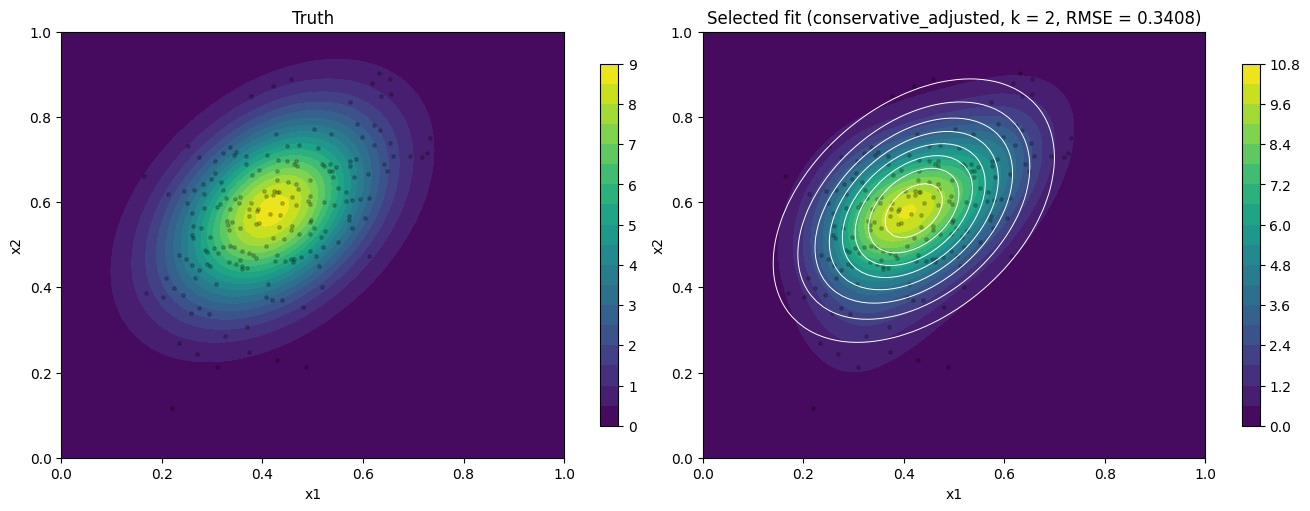

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

truth_contour = axes[0].contourf(
    surface_mesh_x1,
    surface_mesh_x2,
    true_density_surface,
    levels=18,
    cmap="viridis",
)
axes[0].scatter(data["x1"], data["x2"], s=6, color="black", alpha=0.20)
axes[0].set_title("Truth")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
fig.colorbar(truth_contour, ax=axes[0], shrink=0.85)

fit_contour = axes[1].contourf(
    surface_mesh_x1,
    surface_mesh_x2,
    best_surface,
    levels=18,
    cmap="viridis",
)
axes[1].contour(
    surface_mesh_x1,
    surface_mesh_x2,
    true_density_surface,
    levels=8,
    colors="white",
    linewidths=0.7,
)
axes[1].scatter(data["x1"], data["x2"], s=6, color="black", alpha=0.20)
axes[1].set_title(
    f"Selected fit ({best_summary['selection_method']}, k = {best_params['k']}, RMSE = {best_summary['pointwise_rmse']:.4f})"
)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
fig.colorbar(fit_contour, ax=axes[1], shrink=0.85)

plt.show()

## 3D Surface View

A 3D surface plot makes it easier to inspect how the truth, the raw Optuna-best fit, and the final selected fit bend over `[0, 1]^2` on the same vertical scale.

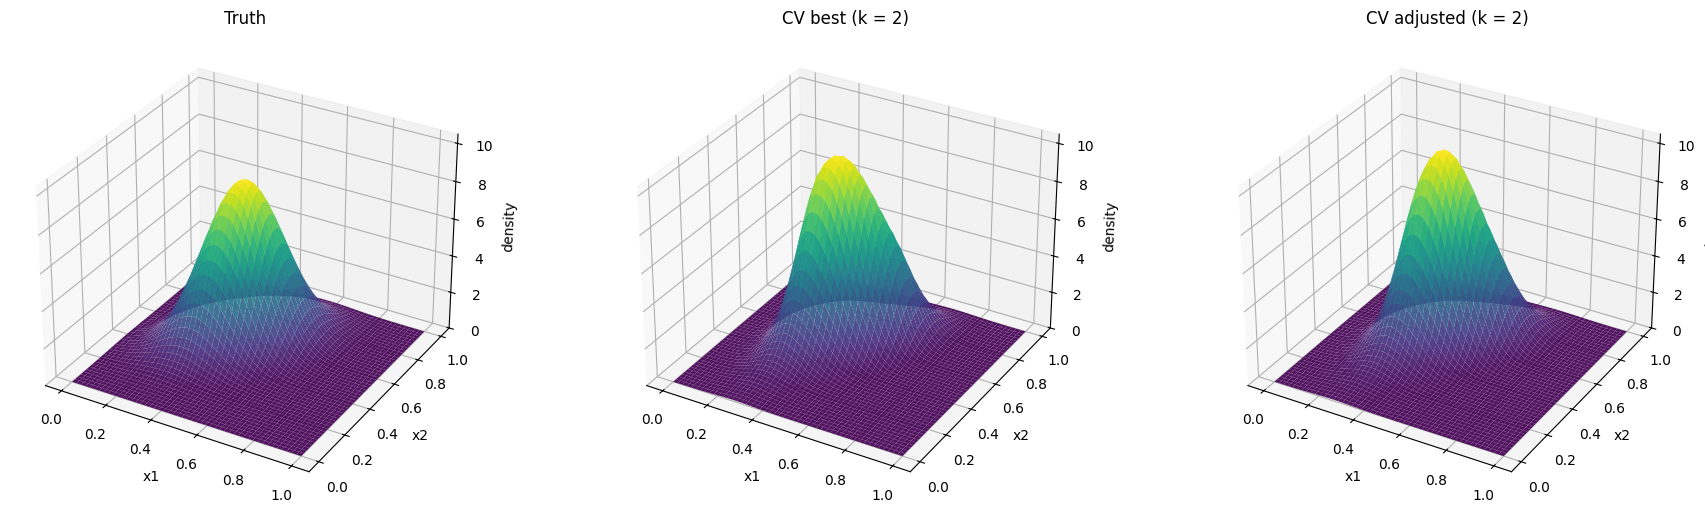

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

surface3d_points_per_dim = 50
surface3d_axis_x1 = np.linspace(support[0][0], support[0][1], surface3d_points_per_dim)
surface3d_axis_x2 = np.linspace(support[1][0], support[1][1], surface3d_points_per_dim)
surface3d_mesh_x1, surface3d_mesh_x2 = np.meshgrid(
    surface3d_axis_x1,
    surface3d_axis_x2,
    indexing="xy",
)
surface3d_grid = np.column_stack([surface3d_mesh_x1.ravel(), surface3d_mesh_x2.ravel()])

selected_title = (
    f"CV adjusted (k = {best_params['k']})"
    if not same_as_optuna
    else f"CV adjusted (= CV best, k = {best_params['k']})"
)
surface_panels = [
    ("Truth", dgp.compute_density(surface3d_grid).reshape(surface3d_mesh_x1.shape)),
    (
        f"CV best (k = {optuna_params['k']})",
        optuna_model.get_density_at_points(surface3d_grid).reshape(surface3d_mesh_x1.shape),
    ),
    (
        selected_title,
        best_model.get_density_at_points(surface3d_grid).reshape(surface3d_mesh_x1.shape),
    ),
]
z_max = max(float(surface.max()) for _, surface in surface_panels)

fig = plt.figure(figsize=(18, 5), constrained_layout=True)
for plot_idx, (title, surface_values) in enumerate(surface_panels, start=1):
    ax = fig.add_subplot(1, 3, plot_idx, projection="3d")
    ax.plot_surface(
        surface3d_mesh_x1,
        surface3d_mesh_x2,
        surface_values,
        cmap="viridis",
        linewidth=0,
        antialiased=True,
        alpha=0.92,
    )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("density")
    ax.set_zlim(0.0, 1.02 * z_max)

plt.show()

## Notes

This notebook now uses the reusable package API from `src.haldensity.multivariate` for all fitting work, and layers a notebook-local Optuna CV loop on top for hyperparameter selection. The longer `examples/multivar-HAL/multivar-basis-demo.ipynb` notebook remains the theory and prototype notebook, while this one is meant to be the lighter usage example with a tuning workflow.